# 01 - Explore ESA-ADB Mission1 Dataset

**Dataset facts :**
- 14 years of real spacecraft telemetry (~14.7M points in train, 6 months in test)
- 89 columns total : `id` + 87 channels + `is_anomaly`
- 87 channels = 58 target + 18 auxiliary + 11 telecommands (`telecommand_` prefix)
- Timestamps replaced by integer `id` column (no datetime)
- Label `is_anomaly = 1` if at least one target channel is anomalous at that point
- Starter channels recommended by dataset authors : `channel_41` -> `channel_46`

**Objectives:**
- Confirm schema : telemetry features, `is_anomaly` target
- Audit data quality : shape, dtypes, missing values, value ranges
- Understand anomaly ratio and label distribution
- Identify target channels and their role
- Save summary artefacts to `results/metrics/`

---
## Imports & Paths

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path("..")
DATA_RAW = ROOT / "data" / "raw" / "ESA-Mission1"
RESULTS_DIR = ROOT / "results" / "metrics"
FIGURES_DIR = ROOT / "results" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_RAW / "train.parquet"
TEST_PATH = DATA_RAW / "test.parquet"
TARGETS_PATH = DATA_RAW / "target_channels.csv"

for p in [TRAIN_PATH, TEST_PATH, TARGETS_PATH]:
    status = "File exist :" if p.exists() else "Missing file"
    print(f"{status} {p}")

File exist : ../data/raw/ESA-Mission1/train.parquet
File exist : ../data/raw/ESA-Mission1/test.parquet
File exist : ../data/raw/ESA-Mission1/target_channels.csv


---
## Load Files

In [2]:
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)
targets = pd.read_csv(TARGETS_PATH)

print(f"train   : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"test    : {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"targets : {targets.shape[0]} rows x {targets.shape[1]} columns")

train   : 14,728,321 rows x 89 columns
test    : 521,280 rows x 88 columns
targets : 58 rows x 1 columns


---
## Columns Inspection

In [3]:
# Fixed column roles (confirmed from data inspection)
ID_COL    = "id"
LABEL_COL = "is_anomaly"

# Target channels : 58 channels monitored for anomalies
target_channel_list = targets["target_channels"].tolist()

# Telecommand channels : binary control commands
telecommand_cols = [c for c in train.columns if c.startswith("telecommand_")]

# Auxiliary channels : remaining numeric channels (not target, not telecommand, not id/label)
exclude = set(target_channel_list + telecommand_cols + [ID_COL, LABEL_COL])
auxiliary_cols = [c for c in train.columns if c not in exclude]

# All feature cols used for modelling (no id, no label)
feature_cols = target_channel_list + auxiliary_cols + telecommand_cols

print(f"{'Column':<25} {'Count':>6}")
print("-" * 33)
print(f"{'Total columns':<25} {train.shape[1]:>6}")
print(f"{'id (index)':<25} {'1':>6}")
print(f"{'is_anomaly (label)':<25} {'1':>6}")
print(f"{'Target channels':<25} {len(target_channel_list):>6}  (monitored for anomalies)")
print(f"{'Auxiliary channels':<25} {len(auxiliary_cols):>6}  (environmental variables)")
print(f"{'Telecommand channels':<25} {len(telecommand_cols):>6}  (binary control commands)")
print(f"\nTelecommands : {telecommand_cols}")
print(f"Auxiliary    : {auxiliary_cols}")

Column                     Count
---------------------------------
Total columns                 89
id (index)                     1
is_anomaly (label)             1
Target channels               58  (monitored for anomalies)
Auxiliary channels            18  (environmental variables)
Telecommand channels          11  (binary control commands)

Telecommands : ['telecommand_244', 'telecommand_350', 'telecommand_351', 'telecommand_352', 'telecommand_353', 'telecommand_354', 'telecommand_36', 'telecommand_376', 'telecommand_38', 'telecommand_39', 'telecommand_40']
Auxiliary    : ['channel_1', 'channel_10', 'channel_11', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_6', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_8', 'channel_9']


In [4]:
print(f"  Train  : {train[ID_COL].min():,}  ->  {train[ID_COL].max():,}")
print(f"  Test   : {test[ID_COL].min():,}   ->  {test[ID_COL].max():,}")
print(f"  Train length : {len(train):,} points (~14 years)")
print(f"  Test  length : {len(test):,} points (~6 months)")
print(f"\n  Index is contiguous : {(train[ID_COL].diff().dropna() == 1).all()}")

  Train  : 0  ->  14,728,320
  Test   : 14,728,321   ->  15,249,600
  Train length : 14,728,321 points (~14 years)
  Test  length : 521,280 points (~6 months)

  Index is contiguous : True


---
## Missing values

In [5]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    report = pd.DataFrame({"missing_count": miss, "missing_pct": pct})
    report = report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
    if report.empty:
        print(f"{name}: No missing values")
    else:
        print(f"{name}: ⚠️  {len(report)} columns with missing values")
        display(report.head(20))
    return report

train_miss = missing_report(train, "train")
test_miss  = missing_report(test,  "test")

train: No missing values
test: No missing values


In [6]:
if not train_miss.empty:
    top_miss = train_miss.head(20)
    fig, ax  = plt.subplots(figsize=(10, max(3, len(top_miss) * 0.4)))
    ax.barh(top_miss.index[::-1], top_miss["missing_pct"][::-1], color="#E8533F")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Train — Top Missing Value Columns")
    ax.axvline(5, ls="--", color="gray", lw=0.8, label="5 % threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "missing_values_train.png", dpi=150)
    plt.show()
else:
    print("No missing values to plot.")

No missing values to plot.


In [7]:
display(Markdown("### Dtypes"))
display(train.dtypes.to_frame("dtype").T)

display(Markdown("### Target channels — first 5 rows"))
display(train[target_channel_list[:6]].head())

display(Markdown("### Telecommand channels — value counts (binary check)"))
for col in telecommand_cols:
    vc = train[col].value_counts()
    print(f"  {col:<25}  {dict(vc)}")

### Dtypes

,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,channel_18,channel_19,channel_2,channel_20,channel_21,channel_22,channel_23,channel_24,channel_25,channel_26,channel_27,channel_28,channel_29,channel_3,channel_30,channel_31,channel_32,channel_33,channel_34,channel_35,...,channel_62,channel_63,channel_64,channel_65,channel_66,channel_67,channel_68,channel_69,channel_7,channel_70,channel_71,channel_72,channel_73,channel_74,channel_75,channel_76,channel_8,channel_9,telecommand_244,telecommand_350,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
dtype,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,...,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,uint8


### Target channels — first 5 rows

,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17
0,0.3172,0.3718,0.2972,0.1301,0.7668,0.3495
1,0.3172,0.3718,0.2972,0.1301,0.7668,0.3495
2,0.3172,0.3718,0.2972,0.1301,0.7668,0.3495
3,0.3172,0.3718,0.2972,0.1301,0.7668,0.3495
4,0.3172,0.3718,0.2972,0.1301,0.7668,0.3495


### Telecommand channels — value counts (binary check)

  telecommand_244            {0.0: np.int64(14728308), 1.0: np.int64(13)}
  telecommand_350            {0.0: np.int64(14728265), 1.0: np.int64(56)}
  telecommand_351            {0.0: np.int64(14728297), 1.0: np.int64(24)}
  telecommand_352            {0.0: np.int64(14728295), 1.0: np.int64(26)}
  telecommand_353            {0.0: np.int64(14728293), 1.0: np.int64(28)}
  telecommand_354            {0.0: np.int64(14728293), 1.0: np.int64(28)}
  telecommand_36             {0.0: np.int64(14728255), 1.0: np.int64(66)}
  telecommand_376            {0.0: np.int64(14728275), 1.0: np.int64(46)}
  telecommand_38             {0.0: np.int64(14728286), 1.0: np.int64(35)}
  telecommand_39             {0.0: np.int64(14728283), 1.0: np.int64(38)}
  telecommand_40             {0.0: np.int64(14728283), 1.0: np.int64(38)}


---
## Anomaly Label Distribution

In [8]:
vc = train[LABEL_COL].value_counts()
n_total = len(train)
n_anomaly = int(vc.get(1, 0))
n_normal = int(vc.get(0, 0))
ratio = n_anomaly / n_total * 100

print(f"Total samples               : {n_total:,}")
print(f"Normal  (0)                 : {n_normal:,}  ({100 - ratio:.2f} %)")
print(f"Anomaly (1)                 : {n_anomaly:,}  ({ratio:.2f} %)")
print(f"Imbalance ratio (N/A)       : {n_normal/max(n_anomaly,1):.1f}:1")

Total samples               : 14,728,321
Normal  (0)                 : 13,184,217  (89.52 %)
Anomaly (1)                 : 1,544,104  (10.48 %)
Imbalance ratio (N/A)       : 8.5:1


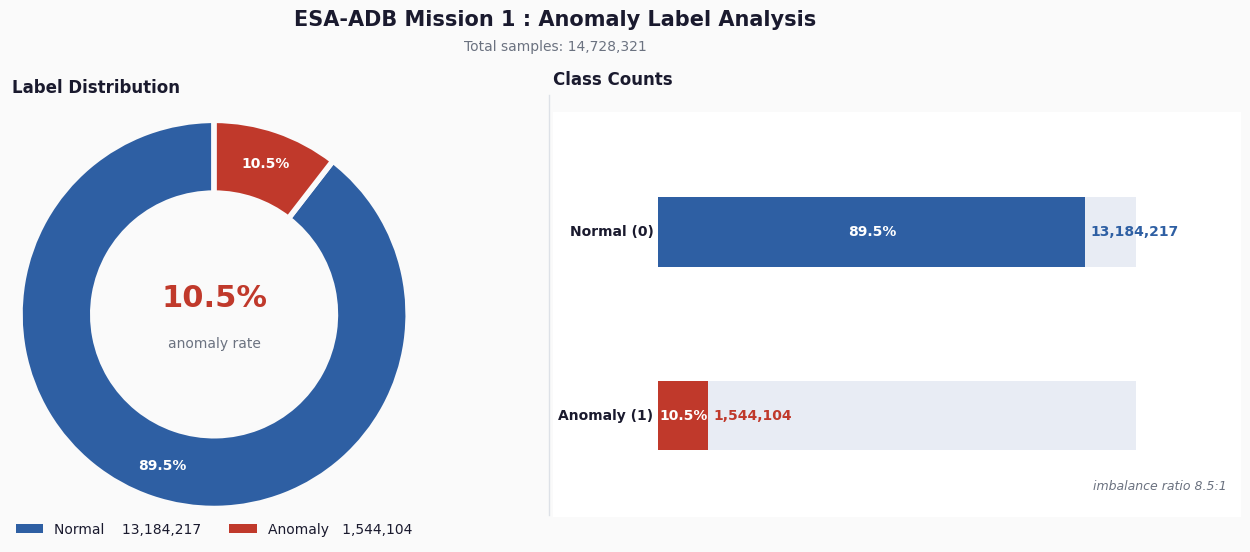

In [9]:
BG        = "#FAFAFA"
PANEL     = "#FFFFFF"
NORMAL_C  = "#2E5FA3"
ANOMALY_C = "#C0392B"
TEXT_DARK = "#1A1A2E"
TEXT_GRAY = "#6B7280"
ACCENT    = "#E8ECF4"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Donut
_, _, autotexts = axes[0].pie(
    [n_normal, n_anomaly],
    colors=[NORMAL_C, ANOMALY_C],
    startangle=90,
    autopct="%1.1f%%",
    pctdistance=0.82,
    radius=1.2,
    wedgeprops={"edgecolor": BG, "linewidth": 4, "width": 0.45},
    labeldistance=1.15,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color("white")
    at.set_fontweight("bold")

axes[0].text(0,  0.10, f"{ratio:.1f}%",   ha="center", va="center",
             fontsize=22, fontweight="bold", color=ANOMALY_C)
axes[0].text(0, -0.18, "anomaly rate",    ha="center", va="center",
             fontsize=10, color=TEXT_GRAY)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[
        Patch(facecolor=NORMAL_C,  label=f"Normal    {n_normal:,}"),
        Patch(facecolor=ANOMALY_C, label=f"Anomaly   {n_anomaly:,}"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.08),
    frameon=False, fontsize=10, labelcolor=TEXT_DARK, ncol=2
)
axes[0].set_title("Label Distribution", fontsize=12, fontweight="bold",
                  color=TEXT_DARK, pad=14, loc="left")

# Horizontal bars
for yi, val, color, lab in zip([1, 0],
                                [n_normal, n_anomaly],
                                [NORMAL_C, ANOMALY_C],
                                ["Normal (0)", "Anomaly (1)"]):
    axes[1].barh(yi, n_total, height=0.38, color=ACCENT, zorder=1)
    axes[1].barh(yi, val,     height=0.38, color=color,  zorder=2)
    axes[1].text(-n_total * 0.01, yi, lab,
                 ha="right", va="center", fontsize=10,
                 fontweight="bold", color=TEXT_DARK)
    axes[1].text(val + n_total * 0.01, yi, f"{val:,}",
                 ha="left", va="center", fontsize=10,
                 color=color, fontweight="bold")
    axes[1].text(val / 2, yi, f"{val/n_total*100:.1f}%",
                 ha="center", va="center", fontsize=10,
                 color="white", fontweight="bold")

axes[1].set_xlim(-n_total * 0.22, n_total * 1.22)
axes[1].set_ylim(-0.55, 1.65)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title("Class Counts", fontsize=12, fontweight="bold",
                  color=TEXT_DARK, pad=20, loc="left")
axes[1].text(0.98, 0.06, f"imbalance ratio {n_normal/max(n_anomaly,1):.1f}:1",
             transform=axes[1].transAxes, ha="right", va="bottom",
             fontsize=9, color=TEXT_GRAY, style="italic")

fig.add_artist(plt.Line2D([0.495, 0.495], [0.08, 0.92],
               transform=fig.transFigure, color="#DDE1E7", linewidth=1))
fig.text(0.5, 1.06, "ESA-ADB Mission 1 : Anomaly Label Analysis",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 1.01, f"Total samples: {n_total:,}",
         ha="center", fontsize=10, color=TEXT_GRAY)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Anomaly Density Over Time

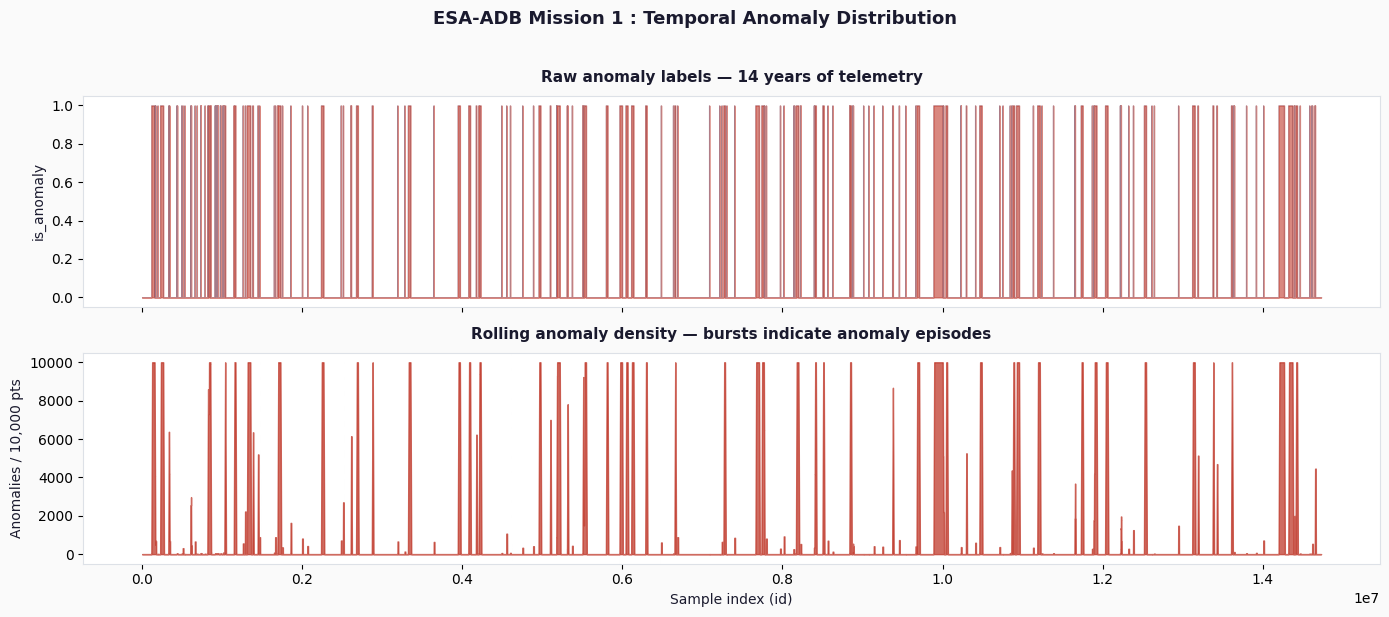

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor=BG, sharex=True)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

idx = train[ID_COL]

# Raw label signal
axes[0].plot(idx, train[LABEL_COL], color=NORMAL_C, alpha=0.3, lw=0.3)
axes[0].fill_between(idx, train[LABEL_COL], color=ANOMALY_C, alpha=0.6)
axes[0].set_ylabel("is_anomaly", color=TEXT_DARK, fontsize=10)
axes[0].set_title("Raw anomaly labels — 14 years of telemetry",
                  fontsize=11, fontweight="bold", color=TEXT_DARK, pad=10)

# Rolling density (window = 10 000 points)
WINDOW = 10_000
rolling_sum = train[LABEL_COL].rolling(window=WINDOW, min_periods=1).sum()
axes[1].fill_between(idx, rolling_sum, color=ANOMALY_C, alpha=0.75)
axes[1].set_ylabel(f"Anomalies / {WINDOW:,} pts", color=TEXT_DARK, fontsize=10)
axes[1].set_xlabel("Sample index (id)", color=TEXT_DARK, fontsize=10)
axes[1].set_title("Rolling anomaly density — bursts indicate anomaly episodes",
                  fontsize=11, fontweight="bold", color=TEXT_DARK, pad=10)

plt.suptitle("ESA-ADB Mission 1 : Temporal Anomaly Distribution",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_temporal.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Starter Channels 41–46
Best subset to develop and test algorithms before scaling to all 87 channels

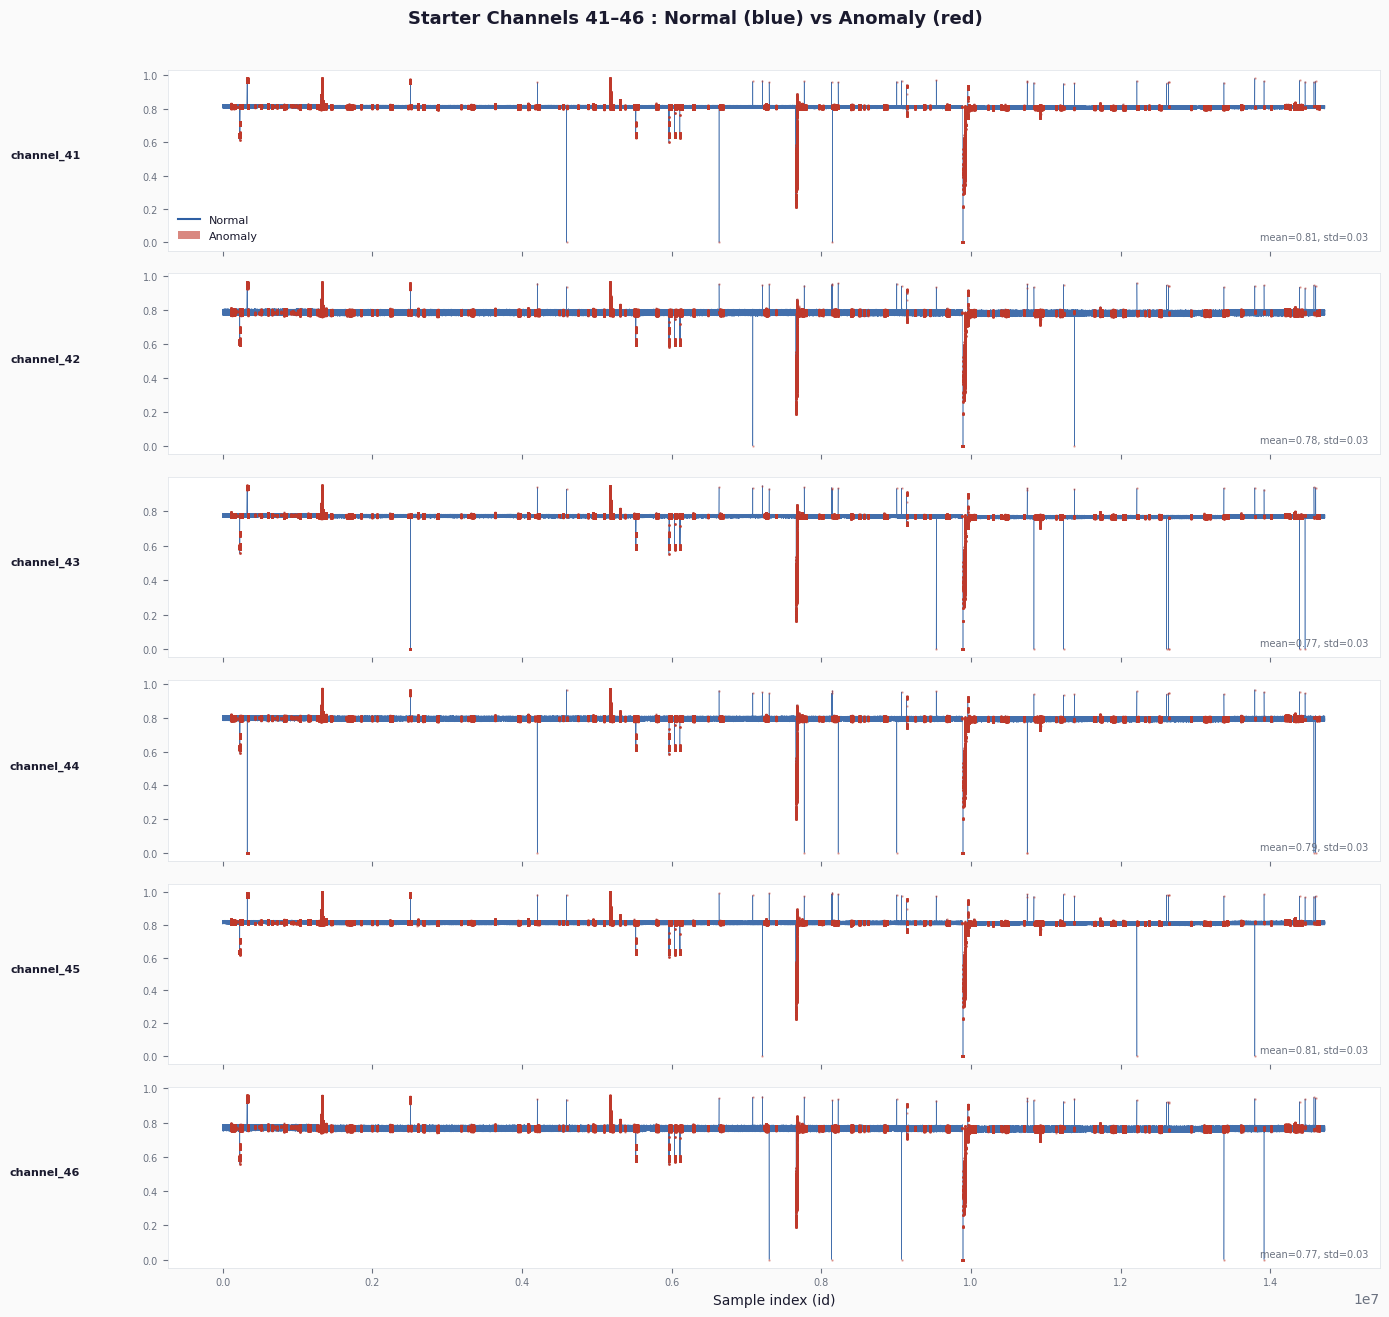

In [11]:
starter_cols = [f"channel_{i}" for i in range(41, 47)]

fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True, facecolor=BG)
fig.patch.set_facecolor(BG)

anomaly_mask = train[LABEL_COL] == 1

for i, col in enumerate(starter_cols):
    ax = axes[i]
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")
        spine.set_linewidth(0.5)

    # Normal signal
    ax.plot(train[ID_COL], train[col], color=NORMAL_C,
            lw=0.4, alpha=0.9, zorder=2)

    # Anomaly points
    ax.scatter(train.loc[anomaly_mask, ID_COL],
               train.loc[anomaly_mask, col],
               color=ANOMALY_C, s=0.5, alpha=0.4, zorder=3)

    ax.set_ylabel(col, fontsize=8, fontweight="bold",
                  color=TEXT_DARK, rotation=0, labelpad=70)
    ax.tick_params(labelsize=7, colors=TEXT_GRAY)

    # Stats annotation
    ax.text(0.99, 0.05,
            f"mean={train[col].mean():.2f}, std={train[col].std():.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=7, color=TEXT_GRAY)

axes[-1].set_xlabel("Sample index (id)", fontsize=10, color=TEXT_DARK)

# Legend
from matplotlib.lines  import Line2D
from matplotlib.patches import Patch
legend_els = [
    Line2D([0], [0], color=NORMAL_C,  lw=1.5, label="Normal"),
    Patch(facecolor=ANOMALY_C, alpha=0.6, label="Anomaly"),
]
axes[0].legend(handles=legend_els,
               loc="lower left",
               frameon=False,
               fontsize=8,
               labelcolor=TEXT_DARK)

plt.suptitle("Starter Channels 41–46 : Normal (blue) vs Anomaly (red)",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "starter_channels.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Feature Statistics

In [12]:
starter_cols = [f"channel_{i}" for i in range(41, 47)]

desc_starter = train[starter_cols].describe().T
desc_starter["range"] = desc_starter["max"] - desc_starter["min"]
desc_starter["skewness"] = train[starter_cols].skew()
desc_starter["kurtosis"] = train[starter_cols].kurtosis()
desc_starter["cv"] = desc_starter["std"] / desc_starter["mean"].replace(0, np.nan)

display(Markdown("### Starter channels 41–46 : Descriptive statistics"))
display(desc_starter)

### Starter channels 41–46 : Descriptive statistics

,count,mean,std,min,25%,50%,75%,max,range,skewness,kurtosis,cv
channel_41,14728321.0000,0.8082,0.0312,0.0000,0.8055,0.8094,0.8141,0.9821,0.9821,-19.6620,460.8421,0.0386
channel_42,14728321.0000,0.7821,0.0310,0.0000,0.7783,0.7831,0.7896,0.9663,0.9663,-18.4753,418.1406,0.0397
channel_43,14728321.0000,0.7686,0.0319,0.0000,0.7664,0.7703,0.7743,0.9507,0.9507,-18.4899,401.4833,0.0416
channel_44,14728321.0000,0.7940,0.0347,0.0000,0.7913,0.7960,0.8008,0.9755,0.9755,-18.4124,388.0532,0.0437
channel_45,14728321.0000,0.8104,0.0314,0.0000,0.8067,0.8118,0.8169,1.0000,1.0000,-19.2298,448.6025,0.0388
channel_46,14728321.0000,0.7656,0.0306,0.0000,0.7611,0.7670,0.7729,0.9595,0.9595,-18.1400,408.8589,0.0399


In [13]:
high_skew = desc_starter[desc_starter["skewness"].abs() > 3] \
            .sort_values("skewness", key=abs, ascending=False)
low_var   = desc_starter[desc_starter["std"] < 1e-6]

print(f"High skew (|skew| > 3)     : {len(high_skew)}  -> log1p candidate")
print(f"Near-zero variance         : {len(low_var)}  -> drop candidate")

if not high_skew.empty:
    display(high_skew[["mean", "std", "min", "max", "skewness"]])
if not low_var.empty:
    display(low_var[["mean", "std", "min", "max"]])

High skew (|skew| > 3)     : 6  -> log1p candidate
Near-zero variance         : 0  -> drop candidate


,mean,std,min,max,skewness
channel_41,0.8082,0.0312,0.0000,0.9821,-19.6620
channel_45,0.8104,0.0314,0.0000,1.0000,-19.2298
channel_43,0.7686,0.0319,0.0000,0.9507,-18.4899
channel_42,0.7821,0.0310,0.0000,0.9663,-18.4753
channel_44,0.7940,0.0347,0.0000,0.9755,-18.4124
channel_46,0.7656,0.0306,0.0000,0.9595,-18.1400


---
## Normal vs Anomaly Feature Distributions (Starter Channels)

In [14]:
train[starter_cols].sample(5)

,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
9066609,0.8102,0.7807,0.7727,0.7945,0.8092,0.7729
8779744,0.8055,0.7807,0.7774,0.7913,0.8058,0.7771
7789644,0.8165,0.7727,0.7679,0.8055,0.8050,0.7678
577312,0.8212,0.7807,0.7735,0.8063,0.8118,0.7704
9729095,0.8141,0.7775,0.7679,0.8031,0.8067,0.7695


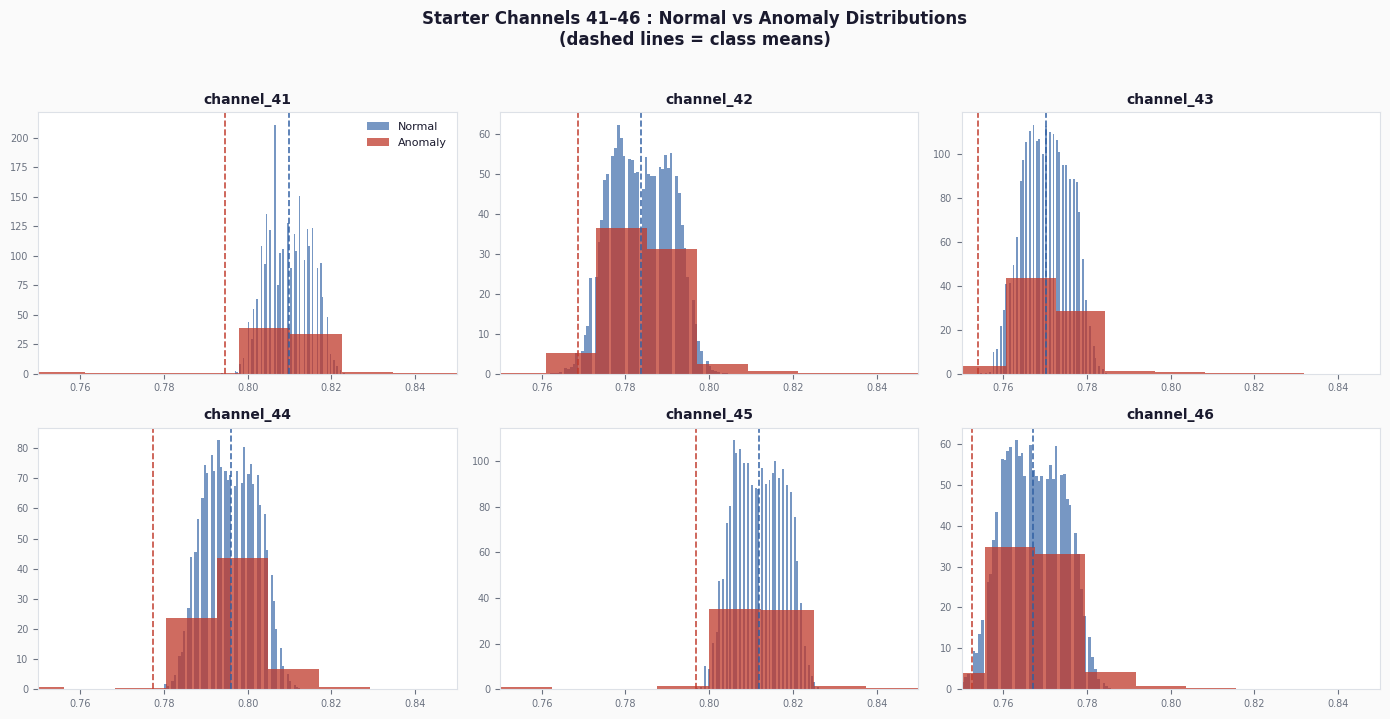

In [15]:
normal_mask  = train[LABEL_COL] == 0
anomaly_mask = train[LABEL_COL] == 1

fig, axes = plt.subplots(2, 3, figsize=(14, 7), facecolor=BG)
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(starter_cols):
    ax = axes[i]
    ax.set_facecolor(PANEL)
    ax.set_xlim(0.75, 0.85)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

    ax.hist(train.loc[normal_mask,  col].dropna(), bins=80, alpha=0.65,
            color=NORMAL_C,  label="Normal",  density=True, lw=0)
    ax.hist(train.loc[anomaly_mask, col].dropna(), bins=80, alpha=0.75,
            color=ANOMALY_C, label="Anomaly", density=True, lw=0)

    ax.set_title(col, fontsize=10, fontweight="bold", color=TEXT_DARK)
    ax.tick_params(labelsize=7, colors=TEXT_GRAY)

    # KDE mean lines
    ax.axvline(train.loc[normal_mask,  col].mean(), color=NORMAL_C,
               lw=1.2, ls="--", alpha=0.9)
    ax.axvline(train.loc[anomaly_mask, col].mean(), color=ANOMALY_C,
               lw=1.2, ls="--", alpha=0.9)

    if i == 0:
        ax.legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)

plt.suptitle("Starter Channels 41–46 : Normal vs Anomaly Distributions\n"
             "(dashed lines = class means)",
             fontsize=12, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "starter_distributions.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Mean Shift During Anomalies (Starter Channels)
Which channel deviate the most from normal? Might be helpful for the future model

### Mean shift per starter channel

,normal_mean,anomaly_mean,abs_delta,delta_pct
channel_44,0.7960,0.7774,0.0186,2.3315
channel_43,0.7703,0.7539,0.0164,2.1263
channel_45,0.8120,0.7969,0.0151,1.8606
channel_41,0.8098,0.7947,0.0151,1.8621
channel_42,0.7837,0.7688,0.0149,1.9035
channel_46,0.7672,0.7525,0.0146,1.9038


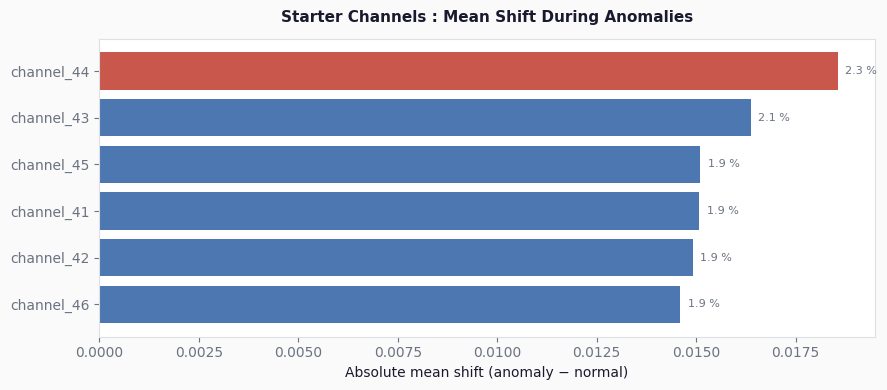

In [16]:
grp = train.groupby(LABEL_COL)[starter_cols].mean().T
grp.columns = ["normal_mean", "anomaly_mean"]
grp["abs_delta"]  = (grp["anomaly_mean"] - grp["normal_mean"]).abs()
grp["delta_pct"]  = grp["abs_delta"] / grp["normal_mean"].replace(0, np.nan) * 100
grp = grp.sort_values("abs_delta", ascending=False)

display(Markdown("### Mean shift per starter channel"))
display(grp)

fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color("#DDE1E7")

colors_bar = [ANOMALY_C if v == grp["abs_delta"].max() else NORMAL_C
              for v in grp["abs_delta"]]
ax.barh(grp.index[::-1], grp["abs_delta"][::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel("Absolute mean shift (anomaly − normal)",
              color=TEXT_DARK, fontsize=10)
ax.set_title("Starter Channels : Mean Shift During Anomalies",
             fontsize=11, fontweight="bold", color=TEXT_DARK, pad=12)
ax.tick_params(colors=TEXT_GRAY)

for bar, (_, row) in zip(ax.patches, grp[::-1].iterrows()):
    ax.text(bar.get_width() + grp["abs_delta"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['delta_pct']:.1f} %",
            va="center", fontsize=8, color=TEXT_GRAY)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "starter_mean_shift.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Correlation Heatmap (Starter Channels)

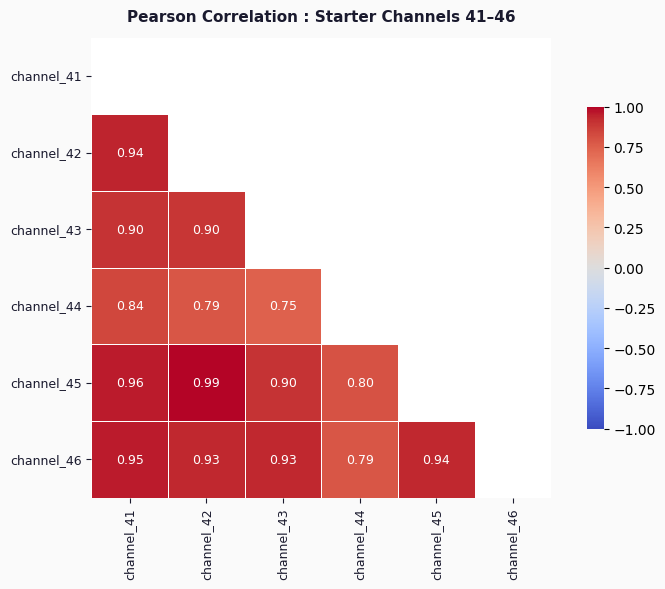

In [17]:
corr = train[starter_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(PANEL)

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.4, square=True,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Pearson Correlation : Starter Channels 41–46",
             fontsize=11, fontweight="bold", color=TEXT_DARK, pad=12)
ax.tick_params(labelsize=9, colors=TEXT_DARK)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "starter_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Export Summary

In [18]:
summary = {
    "dataset": {
        "mission"             : "ESA-Mission1",
        "description"         : "14 years spacecraft telemetry",
        "timestamp_type"      : "integer_id",
        "total_feature_cols"  : train.shape[1] - 2,   # exclude id + label
        "target_channels"     : target_channel_list,
        "auxiliary_channels"  : auxiliary_cols,
        "telecommand_channels": telecommand_cols,
        "starter_channels"    : starter_cols,
        "label_col"           : LABEL_COL,
    },
    "train": {
        "rows"          : int(train.shape[0]),
        "columns"       : int(train.shape[1]),
        "n_anomaly"     : n_anomaly,
        "n_normal"      : n_normal,
        "anomaly_ratio" : float(ratio),
        "pos_weight"    : float(n_normal / max(n_anomaly, 1)),
        "missing_cols"  : train_miss.index.tolist(),
    },
    "test": {
        "rows"   : int(test.shape[0]),
        "columns": int(test.shape[1]),
    },
    "starter_channels_eda": {
        "high_skew_cols": high_skew.index.tolist(),
        "zero_var_cols" : low_var.index.tolist(),
        "most_shifted"  : grp["abs_delta"].idxmax(),
        "mean_shift"    : grp.to_dict(),
    }
}

out_json = RESULTS_DIR / "eda_summary_mission1.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2, default=str)

desc_starter.to_csv(RESULTS_DIR / "starter_channels_stats.csv")
grp.to_csv(RESULTS_DIR / "starter_channels_mean_shift.csv")

print(f"{out_json} saved")
print(f"{RESULTS_DIR / 'starter_channels_stats.csv'} saved")
print(f"{RESULTS_DIR / 'starter_channels_mean_shift.csv'} saved")

../results/metrics/eda_summary_mission1.json saved
../results/metrics/starter_channels_stats.csv saved
../results/metrics/starter_channels_mean_shift.csv saved
